# Phase IV — Evidential Deep Learning: implementation and experiments
**Pleural effusion classification, ChestMNIST.**

Compare an evidential MLP with a matched softmax MLP: the same 50 PCA inputs, architecture, training budget, optimizer, seeds and corrupted labels. Both networks are trained from scratch. This is a lightweight feature-based adaptation, not a reproduction of a medical CNN or proof of state-of-the-art performance.

Reference: Sensoy, Kaplan and Kandemir, *Evidential Deep Learning to Quantify Classification Uncertainty*, NeurIPS 2018: https://arxiv.org/abs/1806.01768 . The loss follows their expected squared-error objective, predictive variance and annealed KL regularization. We use softplus rather than ReLU to produce nonnegative evidence. Full medical literature comparison and article writing remain separate tasks.

## 1. Setup
Use the Phase I environment. Additional dependency: CPU-only PyTorch. From TP1: `phase_1/.venv/bin/python -m pip install torch --index-url https://download.pytorch.org/whl/cpu`.

Run after Phase III, which defines the three corruption seeds and saves noisy labels. No test-based tuning is allowed.

In [1]:
from pathlib import Path
import copy, json, time, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, torch, mlflow
from torch import nn
from torch.nn import functional as F
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss, precision_recall_curve)

torch.set_num_threads(2)
cwd=Path.cwd()
ROOT=next((p for p in (cwd,cwd.parent) if (p/'chestmnist(1)').exists()),None)
if ROOT is None: raise FileNotFoundError('Open from TP1 or phase_4.')
OUT=ROOT/'phase_4'/'outputs'; OUT.mkdir(parents=True,exist_ok=True)
P1=ROOT/'phase_1'/'outputs'; P2=ROOT/'phase_2'/'outputs'; P3=ROOT/'phase_3'/'outputs'
DATA=ROOT/'chestmnist(1)'
SEEDS=[42,43,44]; MAX_EPOCHS=50; BATCH_SIZE=256; LR=0.001; PATIENCE=10
mlflow.set_tracking_uri('sqlite:///'+str((ROOT/'phase_3'/'mlflow.db').resolve()))
name='ChestMNIST_EDL_vs_Softmax'
if mlflow.get_experiment_by_name(name) is None:
    mlflow.create_experiment(name,artifact_location=(ROOT/'phase_4'/'mlartifacts').resolve().as_uri())
mlflow.set_experiment(name)
print('PyTorch:',torch.__version__,'CPU training; output:',OUT.resolve())

2026/10/08 06:52:26 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /home/raoul-ossombe/Desktop/2026-2027/deep learning/TP1/phase_1/.venv/lib/python3.12/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


PyTorch: 2.14.1+cpu CPU training; output: /home/raoul-ossombe/Desktop/2026-2027/deep learning/TP1/phase_4/outputs


## 2. Identical data for both networks
Load the original training indices and Phase II preprocessing. The PCA/scaler is not refitted. Each seed reuses Phase III's noisy labels. Validation and test labels remain unchanged.

In [2]:
indices=np.load(P1/'train_indices.npy',allow_pickle=False)
preprocessing=joblib.load(P2/'preprocessing.joblib')
def data(split,selected=None):
    x=np.load(DATA/f'{split}_images.npy',mmap_mode='r',allow_pickle=False)
    y=np.load(DATA/f'{split}_labels.npy',mmap_mode='r',allow_pickle=False)[:,2].astype(int)
    if selected is not None: x,y=x[selected],y[selected]
    features=np.asarray(x,dtype=np.float32).reshape(len(x),-1)/255.0
    return torch.from_numpy(preprocessing.transform(features).astype(np.float32)),y
X_train,y_train=data('train',indices)
X_val,y_val=data('val'); X_test,y_test=data('test')
noisy={s:np.load(P3/f'noisy_train_labels_seed{s}.npy',allow_pickle=False) for s in SEEDS}
noise_protocol=json.loads((P3/'noise_protocol.json').read_text())
for s in SEEDS:
    assert noisy[s].shape==y_train.shape
    assert np.count_nonzero(noisy[s]!=y_train)==noise_protocol['flipped_count']
    assert np.all(y_train[noisy[s]!=y_train]==noise_protocol['minority_class'])
print('Training features:',tuple(X_train.shape),'test positives:',int(y_test.sum()))

Training features: (10000, 50) test positives: 2754


## 3. What the evidential head predicts
For each class k: evidence e_k = softplus(output_k), alpha_k = e_k + 1, S = sum(alpha).
The predictive mean is p_k = alpha_k/S; vacuity (uncommitted uncertainty) is u=K/S with K=2.

The EDL loss is squared error of the predictive mean plus Dirichlet predictive variance, with KL divergence of adjusted alpha to the uniform Dirichlet. The adjusted correct-class alpha is 1; incorrect-class evidence is penalized. Annealing increases the KL coefficient over ten epochs.

Softmax uses cross-entropy. EDL loss and cross-entropy are different objectives: their numerical values should not be ranked against each other. No class weighting is used in either model.

In [3]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(50,64),nn.ReLU(),
            nn.Linear(64,32),nn.ReLU(),nn.Linear(32,2))
    def forward(self,x): return self.net(x)

def dirichlet_kl(alpha):
    total=alpha.sum(dim=1,keepdim=True)
    K=alpha.shape[1]
    return (torch.lgamma(total).squeeze(1)-torch.lgamma(alpha).sum(1)
            -torch.lgamma(alpha.new_tensor(float(K)))
            +((alpha-1)*(torch.digamma(alpha)-torch.digamma(total))).sum(1))

def evidential_loss(logits,labels,epoch):
    alpha=F.softplus(logits)+1
    total=alpha.sum(1,keepdim=True)
    mean=alpha/total
    target=F.one_hot(labels,num_classes=2).to(alpha.dtype)
    squared=((target-mean)**2).sum(1)
    variance=(alpha*(total-alpha)/(total**2*(total+1))).sum(1)
    adjusted=target+(1-target)*alpha
    annealing=min(1.0,epoch/10)
    return (squared+variance+annealing*dirichlet_kl(adjusted)).mean()

@torch.no_grad()
def probabilities(model,X,kind):
    model.eval(); logits=model(X)
    if kind=='EDL':
        alpha=F.softplus(logits)+1
        p=alpha/alpha.sum(1,keepdim=True)
        uncertainty=2/alpha.sum(1)
    else:
        p=F.softmax(logits,dim=1)
        uncertainty=-(p*torch.log(p.clamp_min(1e-12))).sum(1)/np.log(2)
    return p.numpy(),uncertainty.numpy()

# Verify KL and gradients against PyTorch's independent Dirichlet implementation.
from torch.distributions import Dirichlet, kl_divergence
example=torch.tensor([[1.,1.],[2.,3.],[7.,1.5]],dtype=torch.float64)
reference=kl_divergence(Dirichlet(example),Dirichlet(torch.ones_like(example)))
assert torch.allclose(dirichlet_kl(example),reference,atol=1e-10)
assert abs(dirichlet_kl(torch.ones(1,2)).item())<1e-6
logits=torch.tensor([[0.,0.],[1.,-1.]],requires_grad=True)
loss=evidential_loss(logits,torch.tensor([0,1]),epoch=5)
loss.backward()
assert torch.isfinite(loss) and torch.isfinite(logits.grad).all()
print('EDL KL formula and finite-gradient checks passed.')

EDL KL formula and finite-gradient checks passed.


## 4. Metrics and uncertainty evaluation
Report the usual classification metrics, binary Brier score and 15-bin expected calibration error (ECE). Lower Brier/ECE is better. ECE uses maximum class probability and prediction correctness; bins and dataset size influence it.

Error-detection ROC-AUC asks whether uncertainty ranks wrong predictions above correct ones. For EDL use vacuity; for softmax use normalized predictive entropy. These uncertainty quantities are different and their raw magnitudes should not be directly compared. No OOD detection or clinical uncertainty claim is tested.

In [4]:
def calibration_error(y,p,bins=15):
    confidence=p.max(axis=1); correct=p.argmax(axis=1)==y
    bin_ids=np.minimum((confidence*bins).astype(int),bins-1)
    value=0.0
    for b in range(bins):
        mask=bin_ids==b
        if mask.any(): value+=mask.mean()*abs(correct[mask].mean()-confidence[mask].mean())
    return float(value)

def metrics(y,p,u):
    pred=p.argmax(axis=1); errors=(pred!=y).astype(int)
    return {'accuracy':accuracy_score(y,pred),'precision':precision_score(y,pred,zero_division=0),
        'recall':recall_score(y,pred,zero_division=0),'f1':f1_score(y,pred,zero_division=0),
        'roc_auc':roc_auc_score(y,p[:,1]),'average_precision':average_precision_score(y,p[:,1]),
        'brier_score':brier_score_loss(y,p[:,1]),'ece_15bins':calibration_error(y,p),
        'error_detection_auc':roc_auc_score(errors,u) if len(np.unique(errors))==2 else float('nan'),
        'mean_uncertainty':float(u.mean())}

## 5. Twelve matched training runs
Two objectives × clean/noisy labels × three seeds. Each pair starts from identical weights and uses the same minibatch order. Adam and weight decay are identical. Select each run's checkpoint by validation AP, with up to 50 epochs and early stopping after ten epochs without improvement (at least 20 epochs).

Log metrics and checkpoint artifacts to local MLflow. Checkpoints contain weights and configuration; input preprocessing is saved separately. Use test only after checkpoint selection.

In [5]:
rows=[]; histories=[]; seed42_predictions={}
for seed in SEEDS:
    for condition in ('clean','noisy'):
        y_fit=torch.tensor(y_train if condition=='clean' else noisy[seed],dtype=torch.long)
        for kind in ('Softmax','EDL'):
            torch.manual_seed(seed); model=Classifier()
            optimizer=torch.optim.Adam(model.parameters(),lr=LR,weight_decay=1e-4)
            generator=torch.Generator().manual_seed(seed)
            best_ap=-np.inf; best_state=None; best_epoch=0; stale=0
            start=time.perf_counter()
            for epoch in range(1,MAX_EPOCHS+1):
                model.train(); permutation=torch.randperm(len(X_train),generator=generator)
                total_loss=0.0
                for batch in permutation.split(BATCH_SIZE):
                    optimizer.zero_grad(); output=model(X_train[batch])
                    loss=evidential_loss(output,y_fit[batch],epoch) if kind=='EDL' else F.cross_entropy(output,y_fit[batch])
                    if not torch.isfinite(loss): raise RuntimeError('Non-finite training loss.')
                    loss.backward(); optimizer.step()
                    total_loss+=float(loss.detach())*len(batch)
                p_val,_=probabilities(model,X_val,kind)
                ap=average_precision_score(y_val,p_val[:,1])
                histories.append({'kind':kind,'condition':condition,'seed':seed,'epoch':epoch,
                    'training_loss':total_loss/len(X_train),'validation_ap':ap})
                if ap>best_ap+1e-6:
                    best_ap=ap; best_state=copy.deepcopy(model.state_dict()); best_epoch=epoch; stale=0
                else: stale+=1
                if epoch>=20 and stale>=PATIENCE: break
            fit_seconds=time.perf_counter()-start
            model.load_state_dict(best_state)
            checkpoint=OUT/f'{kind}_{condition}_seed{seed}.pt'
            torch.save({'state_dict':best_state,'kind':kind,'seed':seed,'condition':condition,
                        'architecture':[50,64,32,2],'best_epoch':best_epoch},checkpoint)
            with mlflow.start_run(run_name=f'{kind}_{condition}_seed{seed}') as run:
                mlflow.log_params({'kind':kind,'condition':condition,'seed':seed,
                    'architecture':'50-64-32-2','learning_rate':LR,'batch_size':BATCH_SIZE,
                    'max_epochs':MAX_EPOCHS,'best_epoch':best_epoch,'epochs_run':epoch,
                    'weight_decay':1e-4,'class_weighting':'none','evidence_activation':'softplus' if kind=='EDL' else 'not_applicable',
                    'minority_noise_rate':0 if condition=='clean' else 0.05,
                    'checkpoint_selection':'validation_AP','threshold':0.5})
                mlflow.log_metric('fit_seconds',fit_seconds)
                for split,X,y in (('validation',X_val,y_val),('test',X_test,y_test)):
                    p,u=probabilities(model,X,kind)
                    values=metrics(y,p,u)
                    mlflow.log_metrics({f'{split}_{k}':float(v) for k,v in values.items() if np.isfinite(v)})
                    rows.append({'kind':kind,'condition':condition,'seed':seed,'split':split,
                        'best_epoch':best_epoch,'epochs_run':epoch,'fit_seconds':fit_seconds,
                        'run_id':run.info.run_id,**values})
                    if split=='test' and seed==42: seed42_predictions[(kind,condition)]=(p,u)
                mlflow.log_artifact(str(checkpoint),artifact_path='model')
                mlflow.log_artifact(str(P2/'preprocessing.joblib'),artifact_path='model')
                mlflow.log_artifact(str(P1/'train_indices.npy'),artifact_path='protocol')
                mlflow.log_artifact(str(P3/'noise_protocol.json'),artifact_path='protocol')
            pd.DataFrame(rows).to_csv(OUT/'run_metrics.csv',index=False)
            pd.DataFrame(histories).to_csv(OUT/'training_history.csv',index=False)
            print(kind,condition,'seed',seed,'best epoch',best_epoch,flush=True)
results=pd.DataFrame(rows)
assert len(results)==24 and results.run_id.nunique()==12
display(results[results.split=='test'])

Softmax clean seed 42 best epoch 12


EDL clean seed 42 best epoch 22


Softmax noisy seed 42 best epoch 11


EDL noisy seed 42 best epoch 22


Softmax clean seed 43 best epoch 9


...

Softmax clean seed 44 best epoch 15


EDL clean seed 44 best epoch 15


Softmax noisy seed 44 best epoch 12


EDL noisy seed 44 best epoch 17


,kind,condition,seed,split,best_epoch,epochs_run,fit_seconds,run_id,accuracy,precision,recall,f1,roc_auc,average_precision,brier_score,ece_15bins,error_detection_auc,mean_uncertainty
1,Softmax,clean,42,test,12,22,0.846182,f00e3dbbd7fa46758e4cb24691689127,0.876165,0.455224,0.044299,0.080741,0.755331,0.289492,0.097766,0.013177,0.757877,0.435581
3,EDL,clean,42,test,22,32,2.089152,1c07a203d43342efb1ec71fc70795a7d,0.877145,0.496063,0.045752,0.083777,0.754105,0.294485,0.099771,0.044568,0.753256,0.328523
5,Softmax,noisy,42,test,11,21,0.884086,65d05ba8d5ae499c8526eb9fc2e2320a,0.877101,0.487395,0.021060,0.040376,0.752608,0.289759,0.098300,0.027884,0.752908,0.376716
7,EDL,noisy,42,test,22,32,2.264073,db689b21a8af4336ae71f08d80b3ae80,0.877502,0.533333,0.017429,0.033755,0.747217,0.290924,0.100082,0.045128,0.745788,0.330635
9,Softmax,clean,43,test,9,20,0.766580,5e70c7fe0f2142b78aeba1d05f1ceefb,0.875719,0.444079,0.049020,0.088293,0.756796,0.292974,0.097648,0.013722,0.760407,0.433440
11,EDL,clean,43,test,14,24,1.335724,e1ba0c1eebd34ceb8e1ab50786351d2a,0.877279,0.504673,0.019608,0.037749,0.751816,0.295484,0.099161,0.042743,0.751327,0.323910
13,Softmax,noisy,43,test,9,20,0.696703,6e9f6db814db4825859b7d24bc729235,0.876343,0.457265,0.038853,0.071620,0.755205,0.292041,0.097682,0.015246,0.757326,0.428604
15,EDL,noisy,43,test,18,28,1.701438,1cdf086ce82245ec99a84cbe10bf2dc3,0.876387,0.464419,0.045025,0.082092,0.752997,0.293326,0.099730,0.044438,0.754304,0.328829
17,Softmax,clean,44,test,15,25,0.910881,0f5c65b6b44040cfb77ad391150b79dd,0.876075,0.462644,0.058460,0.103804,0.754832,0.294407,0.098243,0.024244,0.757434,0.394809
19,EDL,clean,44,test,15,25,1.393522,7ebc112ee50e481eb5ace6bb2b32a4bb,0.877279,0.520000,0.004720,0.009356,0.753022,0.290184,0.100170,0.049462,0.752323,0.339414


## 6. Summaries and classical comparison
Clean minus noisy AP is degradation; negative values mean an observed improvement. Compare absolute performance too. Means and standard deviations summarize seeds, not new patient populations.

Classical runs used default decisions without validation checkpoint selection. The matched softmax network is the primary control for interpreting an EDL effect; architecture and training differences confound comparison with classical models.

In [6]:
metric_names=['accuracy','precision','recall','f1','roc_auc','average_precision',
              'brier_score','ece_15bins','error_detection_auc']
summary=results.groupby(['split','kind','condition'])[metric_names].agg(['mean','std'])
summary.columns=['_'.join(c) for c in summary.columns]
summary=summary.reset_index(); summary.to_csv(OUT/'metrics_summary.csv',index=False)
display(summary[summary.split=='test'])
test=results[results.split=='test']
clean=test[test.condition=='clean'].set_index(['kind','seed'])
noisy=test[test.condition=='noisy'].set_index(['kind','seed'])
drops=(clean[metric_names]-noisy[metric_names]).add_suffix('_clean_minus_noisy').reset_index()
drops.to_csv(OUT/'paired_changes.csv',index=False)
display(drops[['kind','seed','average_precision_clean_minus_noisy']])
classical=pd.read_csv(P3/'metrics_summary.csv')
classical=classical[(classical.split=='test')&(classical.variant=='standard')].copy()
classical['model']=classical.family
neural=summary[summary.split=='test'].copy(); neural['model']=neural.kind
columns=['model','condition','average_precision_mean','average_precision_std','roc_auc_mean','recall_mean','f1_mean']
comparison=pd.concat([classical[columns],neural[columns]],ignore_index=True)
comparison.to_csv(OUT/'classical_and_neural_comparison.csv',index=False)
display(comparison)

,split,kind,condition,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,...,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,brier_score_mean,brier_score_std,ece_15bins_mean,ece_15bins_std,error_detection_auc_mean,error_detection_auc_std
0,test,EDL,clean,0.877234,0.000077,0.506912,0.012125,0.023360,0.020771,0.043627,...,0.752981,0.001145,0.293385,0.002816,0.099700,0.000508,0.045591,0.003474,0.752302,0.000965
1,test,EDL,noisy,0.877041,0.000582,0.499251,0.034463,0.021181,0.022207,0.039340,...,0.750543,0.002987,0.289809,0.004187,0.099746,0.000327,0.042849,0.003368,0.750351,0.004291
2,test,Softmax,clean,0.875986,0.000236,0.453982,0.009344,0.050593,0.007211,0.090946,...,0.755653,0.001021,0.292291,0.002527,0.097886,0.000315,0.017048,0.006238,0.758572,0.001604
3,test,Softmax,noisy,0.876848,0.000438,0.477352,0.017396,0.026991,0.010272,0.050791,...,0.751910,0.003694,0.289079,0.003354,0.098210,0.000489,0.023194,0.006920,0.752820,0.004551


,kind,seed,average_precision_clean_minus_noisy
0,Softmax,42,-0.000267
1,EDL,42,0.003561
2,Softmax,43,0.000933
3,EDL,43,0.002158
4,Softmax,44,0.008970
5,EDL,44,0.005006


,model,condition,average_precision_mean,average_precision_std,roc_auc_mean,recall_mean,f1_mean
0,Gaussian Naive Bayes,clean,0.240192,0.000000,0.715877,0.097313,0.146729
1,Gaussian Naive Bayes,noisy,0.238330,0.002887,0.712306,0.086178,0.133396
2,Gradient boosting,clean,0.262254,0.000036,0.730814,0.001816,0.003615
3,Gradient boosting,noisy,0.262903,0.001968,0.729352,0.000847,0.001690
4,Linear SVM,clean,0.263579,0.000000,0.729153,0.001816,0.003621
5,Linear SVM,noisy,0.262396,0.000615,0.728897,0.001210,0.002416
6,EDL,clean,0.293385,0.002816,0.752981,0.023360,0.043627
7,EDL,noisy,0.289809,0.004187,0.750543,0.021181,0.039340
8,Softmax,clean,0.292291,0.002527,0.755653,0.050593,0.090946
9,Softmax,noisy,0.289079,0.003354,0.751910,0.026991,0.050791


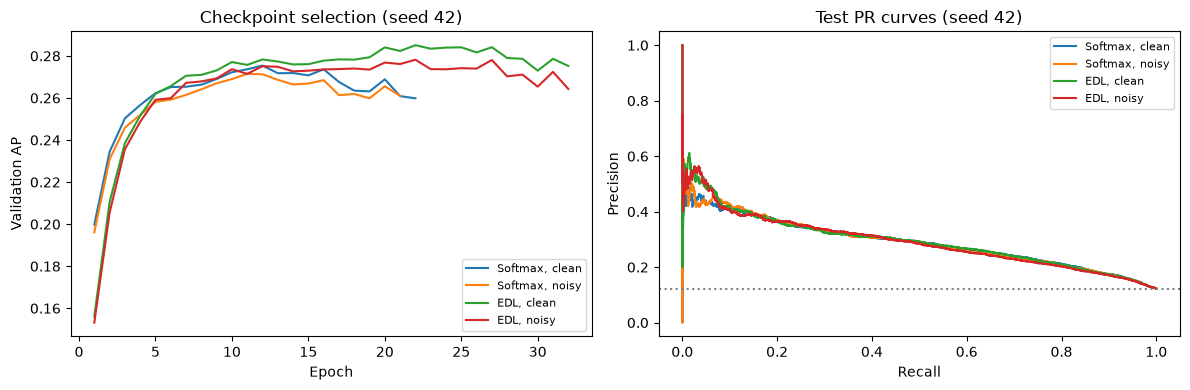

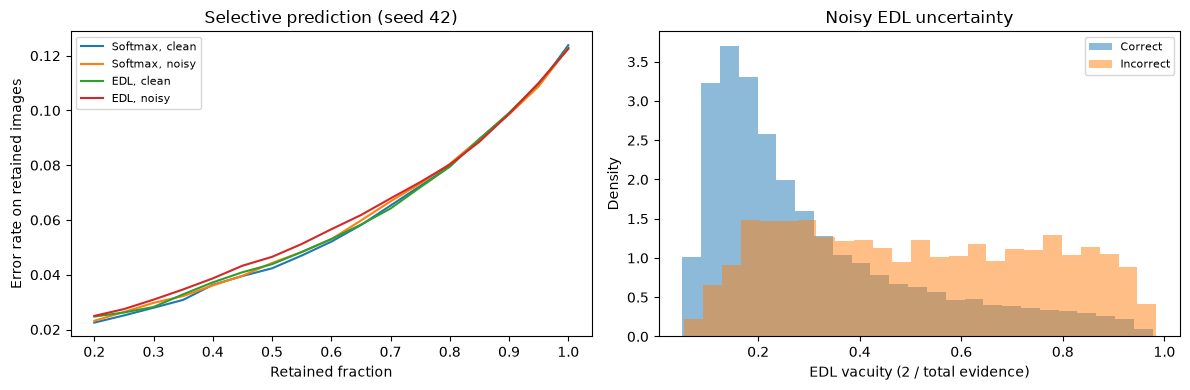

In [7]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
history=pd.DataFrame(histories)
for kind in ('Softmax','EDL'):
    for condition in ('clean','noisy'):
        sub=history[(history.kind==kind)&(history.condition==condition)&(history.seed==42)]
        axes[0].plot(sub.epoch,sub.validation_ap,label=f'{kind}, {condition}')
        p,u=seed42_predictions[(kind,condition)]
        precision,recall,_=precision_recall_curve(y_test,p[:,1])
        axes[1].plot(recall,precision,label=f'{kind}, {condition}')
axes[0].set(xlabel='Epoch',ylabel='Validation AP',title='Checkpoint selection (seed 42)')
axes[1].axhline(y_test.mean(),color='gray',linestyle=':')
axes[1].set(xlabel='Recall',ylabel='Precision',title='Test PR curves (seed 42)')
for ax in axes:ax.legend(fontsize=8)
fig.tight_layout();fig.savefig(OUT/'training_and_pr_curves.png',dpi=150);plt.show()

fig,axes=plt.subplots(1,2,figsize=(12,4))
coverage=np.linspace(0.2,1,17); risk_rows=[]
for kind in ('Softmax','EDL'):
    for condition in ('clean','noisy'):
        p,u=seed42_predictions[(kind,condition)]
        errors=p.argmax(1)!=y_test; order=np.argsort(u,kind='stable'); risks=[]
        for c in coverage:
            retained=order[:max(1,int(c*len(y_test)))]
            risk=float(errors[retained].mean());risks.append(risk)
            risk_rows.append({'kind':kind,'condition':condition,'seed':42,
                'coverage':c,'error_rate':risk,'retained_positive_fraction':float(y_test[retained].mean())})
        axes[0].plot(coverage,risks,label=f'{kind}, {condition}')
# EDL vacuity distributions for the noisy seed-42 run.
p,u=seed42_predictions[('EDL','noisy')]; errors=p.argmax(1)!=y_test
for mask,label in ((~errors,'Correct'),(errors,'Incorrect')):
    if mask.any():axes[1].hist(u[mask],bins=25,density=True,alpha=0.5,label=label)
axes[0].set(xlabel='Retained fraction',ylabel='Error rate on retained images',title='Selective prediction (seed 42)')
axes[1].set(xlabel='EDL vacuity (2 / total evidence)',ylabel='Density',title='Noisy EDL uncertainty')
for ax in axes:ax.legend(fontsize=8)
fig.tight_layout();fig.savefig(OUT/'uncertainty_evaluation.png',dpi=150);plt.show()
pd.DataFrame(risk_rows).to_csv(OUT/'risk_coverage_seed42.csv',index=False)

## 7. Conclusions to write from measured results
Does EDL outperform the matched softmax network in AP, recall or calibration? Does vacuity rank mistakes well? Does rejecting uncertain examples mainly remove positive cases? Inspect retained class proportions before interpreting risk–coverage curves.

EDL is not guaranteed to improve noise robustness or calibrated uncertainty. No independent medical OOD dataset is tested. Distinguish this feature-based implementation from the original paper's architecture and experiments. Avoid claims of clinical safety or state-of-the-art superiority.

Use the exported tables and figures for the article. Explain Dirichlet evidence alongside measured uncertainty performance. Keep the four-solution literature review separate from this empirical experiment.

In [8]:
protocol={'torch':torch.__version__,'python':sys.version,'seeds':SEEDS,
 'architecture':[50,64,32,2],'max_epochs':MAX_EPOCHS,'learning_rate':LR,
 'batch_size':BATCH_SIZE,'checkpoint_selection':'validation AP',
 'edl_loss':'expected squared error + predictive variance + annealed adjusted-Dirichlet KL',
 'evidence_activation':'softplus','reference':'https://arxiv.org/abs/1806.01768',
 'implementation':'feature-based adaptation, not medical CNN reproduction',
 'class_weighting':'none','test_used_for_tuning':False}
(OUT/'edl_protocol.json').write_text(json.dumps(protocol,indent=2))
with mlflow.start_run(run_name='EDL_summary'):
    for filename in ('metrics_summary.csv','paired_changes.csv','classical_and_neural_comparison.csv',
        'training_and_pr_curves.png','uncertainty_evaluation.png','risk_coverage_seed42.csv','edl_protocol.json'):
        mlflow.log_artifact(str(OUT/filename),artifact_path='summary')
print('EDL experiments complete:',OUT.resolve())

EDL experiments complete: /home/raoul-ossombe/Desktop/2026-2027/deep learning/TP1/phase_4/outputs
